# Multi-Filter Colour Composite

Reproject every frame onto a common WCS centred on the target, median-stack
same-filter frames, sky-subtract, and combine with `make_lupton_rgb`.

Cross-telescope (NOT/ALFOSC + LT/IOO + TJO/MEIA2) data is fully supported —
frames are resampled onto the same pixel grid before being combined.

Two grouping schemes are available:

- **Nightly** (`find_nightly_groups` / `make_nightly_pdfs`) — every frame
  taken on the same UTC night (MJD − 0.5) is one composite. Use this when
  you want one PDF per observing night.
- **Temporal window** (`find_temporal_groups` / `make_temporal_group_pdfs`) —
  every frame whose `obs_mjd` falls within ±N days of another is grouped.
  Use this when you want to combine epochs across telescopes that didn't
  observe on exactly the same calendar night, or when the same target was
  observed by multiple instruments within a short window.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from glob import glob
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy.time import Time
import matplotlib.pyplot as plt
from pathlib import Path

import importlib, make_color_simple; importlib.reload(make_color_simple)
from make_color_simple import (
    make_color_composite,
    save_color_pdf,
    find_nightly_groups,
    find_temporal_groups,
    make_nightly_pdfs,
    make_temporal_group_pdfs,
    make_finder_figure,
)

%matplotlib inline

## Step 1: Load FITS metadata

In [2]:
# Collect all FITS files
not_files = glob('/Users/kryanhinds/sedm_phot/data/NOT_imaging/*/*.fits') + \
            glob('/Users/kryanhinds/sedm_phot/data/NOT_20260423-24/*.fits')
tjo_files = glob('/Users/kryanhinds/sedm_phot/data/TJO/*.fits')
lt_files  = glob('/Users/kryanhinds/sedm_phot/data/ZTF26aakjzdt_LT/*/*.fits')

all_files = not_files + tjo_files + lt_files

not_kw = {'filt':'FAFLTNM', 'obs_date':'DATE-OBS', 'inst':'NOT/ALFOSC', 'exp_time':'EXPTIME'}
tjo_kw = {'filt':'FILTER',  'obs_date':['DATE-OBS','TIME-OBS'], 'inst':'TJO/MEIA2', 'exp_time':'EXPTIME'}
lt_kw  = {'filt':'FILTER1', 'obs_date':'DATE-OBS', 'inst':'LT/IOO',     'exp_time':'EXPTIME'}

data = []
for f in all_files:
    try:
        with fits.open(f) as hdul:
            hdr = hdul[0].header
            if 'NOT' in f:
                filt = hdr[not_kw['filt']][0]
                obs_date = hdr[not_kw['obs_date']]
                exp_time = hdr[not_kw['exp_time']]
                inst = not_kw['inst']
            elif 'TJO' in f:
                filt = hdr[tjo_kw['filt']][-1]
                obs_date = Time(hdr[tjo_kw['obs_date'][0]] + 'T' + hdr[tjo_kw['obs_date'][1]]).iso
                exp_time = hdr[tjo_kw['exp_time']]
                inst = tjo_kw['inst']
            elif 'LT' in f:
                filt = hdr[lt_kw['filt']][-1].lower()
                obs_date = hdr[lt_kw['obs_date']]
                exp_time = hdr[lt_kw['exp_time']]
                inst = lt_kw['inst']
            else:
                continue

            obs_mjd = Time(obs_date).mjd + (exp_time/2) / 86400.0
            data.append({
                'filename'  : f,
                'instrument': inst,
                'filter'    : str(filt).lower(),
                'obs_date'  : obs_date,
                'obs_mjd'   : obs_mjd,
                'exp_time'  : exp_time,
                'object'    : hdr.get('OBJECT', 'UNKNOWN').strip(),
            })
    except Exception as e:
        print(f"Error reading {Path(f).name}: {e}")

df = pd.DataFrame(data)
print(f"Loaded {len(df)} images")

Loaded 98 images


## Step 2: Inventory the data — preview both grouping schemes

Run both groupers without producing any PDFs to see what each will give you,
then pick whichever fits your science.

In [3]:
print('=== Nightly groups (UTC noon-to-noon) ===')
for date, g in find_nightly_groups(df, min_filters=2):
    insts = ','.join(sorted(g['instrument'].unique()))
    flts  = ','.join(sorted(g['filter'].unique()))
    print(f"  {date}  ·  {len(g):2d} frames  ·  filters={flts:12s}  ·  {insts}")

print('\n=== Temporal groups (±1 day, NOT+LT only, multi-instrument required) ===')
for date, g in find_temporal_groups(df, time_window_days=1.0,
                                    instruments=['NOT/ALFOSC', 'LT/IOO'],
                                    require_multi_instrument=True,
                                    min_filters=3):
    insts = ','.join(sorted(g['instrument'].unique()))
    flts  = ','.join(sorted(g['filter'].unique()))
    print(f"  {date}  ·  {len(g):2d} frames  ·  filters={flts:12s}  ·  {insts}")

TARGET_COORD = '14:37:16.14 +71:50:30.31'   # transient RA/Dec
TARGET_NAME  = 'ZTF26aakjzdt'                # used in PDF filenames
OUTPUT_DIR   = '/Users/kryanhinds/sedm_phot/nightly_pdfs'
ZOOM_ARCMIN  = 1.0
CIRCLE_ARCSEC = 3.0


=== Nightly groups (UTC noon-to-noon) ===
  2026-03-12  ·   4 frames  ·  filters=g,i,r,z       ·  NOT/ALFOSC
  2026-03-13  ·   6 frames  ·  filters=g,i,r,u,z     ·  NOT/ALFOSC
  2026-03-15  ·   4 frames  ·  filters=g,i,r,z       ·  NOT/ALFOSC
  2026-03-16  ·  12 frames  ·  filters=g,i,r,z       ·  LT/IOO
  2026-03-19  ·   3 frames  ·  filters=g,i,r         ·  TJO/MEIA2
  2026-03-22  ·   3 frames  ·  filters=g,i,r         ·  TJO/MEIA2
  2026-03-28  ·   4 frames  ·  filters=g,i,r,z       ·  NOT/ALFOSC
  2026-04-08  ·   3 frames  ·  filters=g,i,r         ·  TJO/MEIA2
  2026-04-17  ·   3 frames  ·  filters=g,i,r         ·  TJO/MEIA2
  2026-04-18  ·   3 frames  ·  filters=g,i,r         ·  TJO/MEIA2
  2026-04-19  ·  10 frames  ·  filters=g,i,r,z       ·  LT/IOO
  2026-04-20  ·  18 frames  ·  filters=g,i,r         ·  LT/IOO
  2026-04-23  ·  16 frames  ·  filters=g,i,r         ·  LT/IOO,NOT/ALFOSC
  2026-04-25  ·   8 frames  ·  filters=g,i,r         ·  LT/IOO

=== Temporal groups (±1 day, NOT+

## Step 3a: One PDF per night

`make_nightly_pdfs` writes one annotated PDF per night under `output_dir`,
with filename:

    color_<TARGET>_<DATE>_<INSTRUMENTS>.pdf

e.g. `color_ZTF26aakjzdt_2026-04-23_LT-NOT.pdf`. Each PDF shows a 1′ crop
centred on the target with a green circle marking the transient location.

In [4]:

# results = make_nightly_pdfs(
#     df,
#     target_coord  = TARGET_COORD,
#     target_name   = TARGET_NAME,
#     output_dir    = OUTPUT_DIR,
#     zoom_arcmin   = ZOOM_ARCMIN,
#     circle_arcsec = CIRCLE_ARCSEC,
#     cutout_size   = 1024,
#     min_filters   = 3,
#     # instruments  = ['NOT/ALFOSC', 'LT/IOO'],   # uncomment to restrict
#     verbose       = True,
# )

# print(f"\n=== {len(results)} nightly PDFs written to {OUTPUT_DIR} ===")
# for r in results:
#     print(f"  {Path(r['path']).name}")

## Step 3b: One PDF per temporal window

When you want to combine epochs separated by less than a day across telescopes
(e.g., a NOT epoch and an LT epoch from the same night-of-the-week), use
`make_temporal_group_pdfs`. The window is symmetric: ±`time_window_days`.

Filenames get a `winNd[-multi]` suffix on the date so they don't collide with
the nightly outputs:

    color_<TARGET>_<DATE>-win1d-multi_<INSTRUMENTS>.pdf

In [5]:
# TEMPORAL_DIR = '/Users/kryanhinds/sedm_phot/temporal_pdfs'

# # Reproduce the original notebook behaviour: ±1 d, NOT+LT, multi-instrument
# results_t = make_temporal_group_pdfs(
#     df,
#     target_coord  = TARGET_COORD,
#     target_name   = TARGET_NAME,
#     output_dir    = TEMPORAL_DIR,
#     time_window_days         = 1.0,
#     instruments              = ['NOT/ALFOSC', 'LT/IOO'],
#     require_multi_instrument = True,
#     zoom_arcmin   = ZOOM_ARCMIN,
#     circle_arcsec = CIRCLE_ARCSEC,
#     cutout_size   = 1024,
#     min_filters   = 3,
#     verbose       = True,
# )

# print(f"\n=== {len(results_t)} temporal-group PDFs written to {TEMPORAL_DIR} ===")
# for r in results_t:
#     print(f"  {Path(r['path']).name}")

## Step 4: Reference-image colour composite (PS1 + Legacy Survey, all filters)

Use archival reference cutouts to generate a deep *pre-explosion* colour image
of the field. The pipeline auto-stacks frames per filter (so PS1 g + LS g
combine into one g-band stack), then with `filter_bands='all'` blends every
filter into R / G / B by triangular wavelength weighting:

- **g** (473 nm) → pure B
- **r** (622 nm) → mostly G with some B
- **i** (763 nm) → mostly G with some R
- **z** (905 nm) → mostly R with some G
- **y** (960 nm) → pure R

This makes much better use of the data than picking only 3 filters — every
filter contributes to the final colour according to its physical wavelength.

Drop the reference FITS into `/Users/kryanhinds/sedm_phot/data/refs/` with a
filename that contains the filter letter (e.g. `ps1_g.ref.fits`,
`*legacysurvey_g.fits`, `legacysurvey_z.fits`).

In [6]:
import re

REFS_DIR = '/Users/kryanhinds/sedm_phot/data/refs'

def load_ref_df(refs_dir=REFS_DIR):
    """Build a DataFrame from every reference FITS in `refs_dir`.

    Detects survey + filter from the filename. Compatible filenames:
        ps1_<filter>.ref.fits        → PS1
        *legacysurvey_<filter>.fits  → LegacySurvey
    """
    rows = []
    for f in sorted(glob(f'{refs_dir}/*.fits')):
        name = Path(f).name.lower()
        if name.startswith('ps1_'):
            m = re.search(r'ps1_([gri zy])', name)
            survey = 'PS1'
        elif 'legacysurvey' in name:
            m = re.search(r'legacysurvey_?([gri zy])', name)
            survey = 'LegacySurvey'
        else:
            continue
        if not m:
            continue
        rows.append({
            'filename'  : f,
            'instrument': survey,
            'filter'    : m.group(1).lower(),
            'obs_mjd'   : 0.0,
            'exp_time'  : 0.0,
        })
    return pd.DataFrame(rows)

ref_df = load_ref_df()
# ref_df = ref_df.loc[ref_df['instrument']=='PS1']  # restrict to PS1 for now
# drop PS1 g since it has a weirdly large FOV and causes issues with cutout centering
ref_df = ref_df[~((ref_df['instrument']=='PS1') & (ref_df['filter']=='g'))]
print(ref_df)
print('\nfilter counts:')
print(ref_df['filter'].value_counts().sort_index())

                                            filename    instrument filter  \
0  /Users/kryanhinds/sedm_phot/data/refs/ZTF26aak...  LegacySurvey      g   
1  /Users/kryanhinds/sedm_phot/data/refs/ZTF26aak...  LegacySurvey      r   
2  /Users/kryanhinds/sedm_phot/data/refs/legacysu...  LegacySurvey      z   
4  /Users/kryanhinds/sedm_phot/data/refs/ps1_i.re...           PS1      i   
5  /Users/kryanhinds/sedm_phot/data/refs/ps1_r.re...           PS1      r   
6  /Users/kryanhinds/sedm_phot/data/refs/ps1_y.re...           PS1      y   
7  /Users/kryanhinds/sedm_phot/data/refs/ps1_z.re...           PS1      z   

   obs_mjd  exp_time  
0      0.0       0.0  
1      0.0       0.0  
2      0.0       0.0  
4      0.0       0.0  
5      0.0       0.0  
6      0.0       0.0  
7      0.0       0.0  

filter counts:
filter
g    1
i    1
r    2
y    1
z    2
Name: count, dtype: int64


### Build one combined PDF using every filter

`filter_bands='all'` triggers multi-filter mode — all filters in the
DataFrame contribute to R/G/B with weights proportional to their position
in the wavelength range. Same-filter frames from different surveys (PS1 g +
LS g) are stacked together first.

Creating colour composite from 7 frames
Filters available: ['g', 'r', 'i', 'z', 'y']  (counts: [1, 2, 1, 2, 1])
Multi-filter blend mode: every filter contributes.
  g (473 nm) → R=0.00 G=0.00 B=1.00
  r (622 nm) → R=0.00 G=0.61 B=0.39
  i (763 nm) → R=0.19 G=0.81 B=0.00
  z (905 nm) → R=0.77 G=0.23 B=0.00
  y (960 nm) → R=1.00 G=0.00 B=0.00
Target WCS: TAN, pixscale=0.250"/px, size=600×600px (FOV ≈ 2.50')
Centre: RA=219.31725°, Dec=71.84175°

  [g] reprojecting 1 frames...
  [g] σ-clipped weighted-mean stack of 1 frames (Σ exptime=0.0s)
  [r] reprojecting 2 frames...
  [r] σ-clipped weighted-mean stack of 2 frames (Σ exptime=680.0s)
  [i] reprojecting 1 frames...
  [i] σ-clipped weighted-mean stack of 1 frames (Σ exptime=1215.0s)
  [z] reprojecting 2 frames...
  [z] σ-clipped weighted-mean stack of 2 frames (Σ exptime=690.0s)
  [y] reprojecting 1 frames...
  [y] σ-clipped weighted-mean stack of 1 frames (Σ exptime=900.0s)

Fitting + subtracting 2-D background per filter...
  [g] backgr

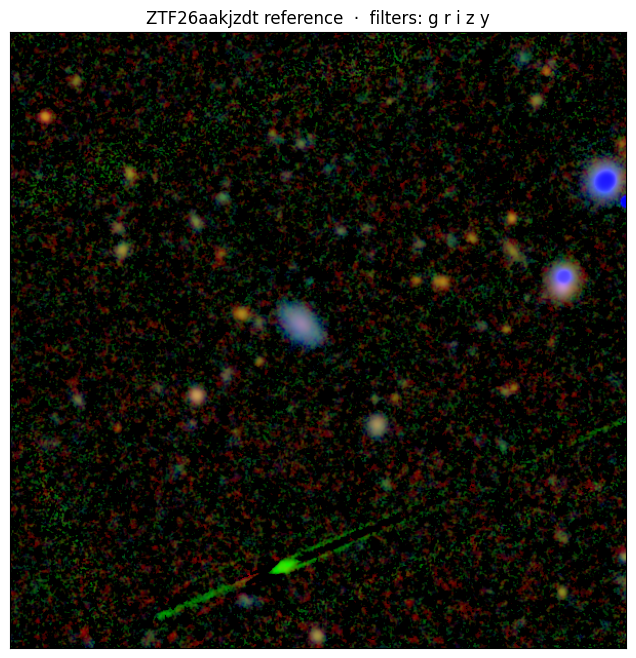

In [7]:
REF_PDF_PATH = f'/Users/kryanhinds/sedm_phot/color_{TARGET_NAME}_ref-PS1-LS.pdf'

# Use the same display sizes as the science PDFs (defined in Step 3a) so
# reference and nightly composites can be compared side-by-side at the same
# physical scale on the sky.
REF_CUTOUT_SIZE = 600        # internal pipeline grid in pixels

rgb_ref, info_ref = make_color_composite(
    ref_df,
    filter_bands  = 'all',          # blend every filter into R/G/B by wavelength
    # filter_bands  = 'grz
    center_coord  = TARGET_COORD,
    cutout_size   = REF_CUTOUT_SIZE,
    Q             = 8.0,
    stretch       = 0.5,
    verbose       = True,
)

print('\nRGB weights per filter:')
for f, (rw, gw, bw) in info_ref['rgb_weights'].items():
    print(f"  {f} ({info_ref['wavelengths'][f]:.0f} nm)  →  R={rw:.2f}  G={gw:.2f}  B={bw:.2f}")

surveys = sorted(ref_df['instrument'].unique())
save_color_pdf(
    rgb_ref, info_ref, REF_PDF_PATH,
    target_coord    = TARGET_COORD,
    zoom_arcmin     = ZOOM_ARCMIN,             # same crop as science
    circle_arcsec   = CIRCLE_ARCSEC,           # same marker as science
    inset_arcsec    = 10.0,                    # 20" zoom inset; None or 0 to disable
    inset_size_frac = 0.30,
    title    = f'{TARGET_NAME}  ·  {"+".join(surveys)} reference  ·  '
               f'{len(info_ref["filters"])} filters',
    subtitle = (f"filters: {' '.join(info_ref['filters'])}  |  "
                f"crop: {ZOOM_ARCMIN*60:.0f}\"  |  "
                f"multi-filter wavelength blend"),
)
print(f'\n✓ Saved {REF_PDF_PATH}')

# Inline preview
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_ref, origin='lower')
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{TARGET_NAME} reference  ·  filters: {' '.join(info_ref['filters'])}")
plt.show()

## Step 5: Tweaking a single group

If a particular group needs custom Q/stretch or a different zoom, call
`make_color_composite` directly and pass it to `save_color_pdf` for a
custom render. Useful knobs:

- `Q`, `stretch`, `minimum` — Lupton parameters
- `channel_weights={'i': 1.0, 'r': 1.2, 'g': 1.4}` — per-filter brightness boost
- `zoom_arcmin` — crop size in arcmin
- `circle_arcsec` — radius of the target marker
- `match_psf=False`, `refine_alignment=False` — disable parts of the pipeline

In [9]:
# # Pick one night manually
# date_to_render = '2026-04-23'
# night_df = next(g for d, g in find_nightly_groups(df) if d == date_to_render)

# rgb, info = make_color_composite(
#     night_df,
#     center_coord    = TARGET_COORD,
#     cutout_size     = 1024,
#     Q               = 8,
#     stretch         = 0.5,
#     channel_weights = {'i': 1.0, 'r': 1.0, 'g': 1.0},
#     verbose         = False,
# )

# # Inline preview of the full field
# fig, ax = plt.subplots(figsize=(7, 7))
# ax.imshow(rgb, origin='lower')
# ax.set_xticks([]); ax.set_yticks([])
# ax.set_title(f"Full {info['fov_arcmin']:.2f}' field  ·  {date_to_render}")
# plt.show()

# # Custom re-render with a 0.5' (30") zoom and bigger marker
# save_color_pdf(
#     rgb, info,
#     output_path   = f'/Users/kryanhinds/sedm_phot/color_{TARGET_NAME}_{date_to_render}_zoom30.pdf',
#     target_coord  = TARGET_COORD,
#     zoom_arcmin   = 0.5,
#     circle_arcsec = 4.0,
#     title    = f'{TARGET_NAME}  ·  {date_to_render}  ·  zoom 30"',
#     subtitle = f"R={info['filters'][0]} G={info['filters'][1]} B={info['filters'][2]}",
# )

## Step 6: Multi-panel finder figure

Combines everything into a single PDF with the layout below — a finder you
can drop into a paper or a circular:

```
+---------------------------+---------------------------+
|                           |                           |
|   Reference (colour)      |   Science (colour)        |
|   + zoom inset            |   + zoom inset            |
|                           |                           |
+--------+--------+--------+--------+
| g sci  | r sci  | i sci  | z sci  |
+--------+--------+--------+--------+
| g ref  | r ref  | i ref  | z ref  |
+--------+--------+--------+--------+
| g sub  | r sub  | i sub  | z sub  |
+--------+--------+--------+--------+
```

The **colour panels** are built in-line from the science / reference
DataFrames (same as Step 3a / Step 4).

The **bottom 12 cutouts** come from a `cutouts` dict you supply, keyed by
filter and then by ``"sci" / "ref" / "sub"``:

```python
cutouts = {
    'g': {
        'sci': '/path/to/g_science_cutout.fits',
        'ref': '/path/to/g_reference_cutout.fits',
        'sub': '/path/to/g_subtraction_cutout.fits',
    },
    'r': {...},
    ...
}
```

Each cutout's WCS is used to draw the target circle at the transient
location; if the WCS isn't usable, the circle defaults to the image centre.
A scale bar is drawn on the top row only (Science).

**Customise the bottom panel** with the `filters` and `rows` arguments:

```python
# Only r/i/z columns:
make_finder_figure(..., filters=['r', 'i', 'z'])

# Drop the reference row, keep sci + difference:
make_finder_figure(..., rows=[('Science','sci'), ('Difference','sub')])

# Reorder: i first, then g, then z:
make_finder_figure(..., filters=['i', 'g', 'z'])
```


In [10]:
# ---------------------------------------------------------------------
# 1. Pick a science epoch
#    (here: the LT+NOT 2026-04-23 night; change to taste)
# ---------------------------------------------------------------------
SCIENCE_DATE = '2026-04-23'
science_epoch_df = next(g for d, g in find_nightly_groups(df, min_filters=3)
                        if d == SCIENCE_DATE)
print(f'Science epoch {SCIENCE_DATE}: {len(science_epoch_df)} frames, '
      f'instruments={sorted(science_epoch_df["instrument"].unique())}')

# ---------------------------------------------------------------------
# 2. Build the cutouts dict.
#
#    Replace these paths with your difference-imaging pipeline outputs
#    (e.g., from sedm_quicklook_pipe.py).
#
#    The dict shape is:  {filter: {'sci': path, 'ref': path, 'sub': path}}
# ---------------------------------------------------------------------
# SUB_DIR = f'/Users/kryanhinds/sedm_phot/data/ZTF26aakjzdt'   # adjust as needed

cutouts = {
    'g': {
        'sci': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_g/GRB260310A_g_Apr23.fits',
        'ref': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_g/ZTF26aakjzdt_legacysurvey_g.fits',
        'sub': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_g/NOT_0423_g.diff.fits',
    },
    'r': {
        'sci': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_r/GRB260310A_r_Apr23.fits',
        'ref': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_r/NOT_0423_r.ps1.fits',
        'sub': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_r/NOT_0423_r.diff.fits',
    },
    'i': {
        'sci': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_i/GRB260310A_i_Apr23.fits',
        'ref': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_i/NOT_0423_i.ps1.fits',
        'sub': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_i/NOT_0423_i.diff.fits',
    },
    'z': {
        'sci': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_z/GRB260310A_z_Apr27_withCR.fits',
        'ref': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_z/NOT_0427_z.ps1.fits',
        'sub': f'/Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_z/NOT_0427_z.diff.fits',
    },
}

# Drop entries that don't actually exist on disk (so missing cutouts
# render as blank panels rather than crashing the figure).
from pathlib import Path
def _trim(d):
    out = {}
    for filt, files in d.items():
        existing = {k: v for k, v in files.items() if Path(v).exists()}
        if existing:
            out[filt] = existing
    return out
cutouts = _trim(cutouts) or cutouts   # keep all if nothing matches yet

print(f'cutouts dict: filters={list(cutouts.keys())}')

Science epoch 2026-04-23: 16 frames, instruments=['LT/IOO', 'NOT/ALFOSC']
cutouts dict: filters=['g', 'r', 'i', 'z']


In [ ]:
# ---------------------------------------------------------------------
# 3. Build the finder figure
# ---------------------------------------------------------------------
FINDER_PDF = f'/Users/kryanhinds/sedm_phot/finder_{TARGET_NAME}_{SCIENCE_DATE}.pdf'

# --- Customise the bottom panel ----------------------------------------
#   filters = ['g', 'r', 'i', 'z']   # all four columns
#   filters = ['r', 'i', 'z']        # only riz
#   filters = None                   # use every key in `cutouts` in dict order
FINDER_FILTERS = ['g', 'r', 'i', 'z']

# Each tuple = (display_label, dict_key in `cutouts`).
#   FINDER_ROWS = [('Science','sci'), ('Difference','sub')]   # drop ref row
FINDER_ROWS = [('Science', 'sci'), ('Reference', 'ref'), ('Difference', 'sub')]

make_finder_figure(
    science_df = science_epoch_df,
    ref_df     = ref_df,
    cutouts    = cutouts,
    target_coord = TARGET_COORD,
    output_path  = FINDER_PDF,

    filters = FINDER_FILTERS,
    rows    = FINDER_ROWS,

    target_name   = TARGET_NAME,
    # Labels auto-build from the DataFrames if left as None — they
    # show 'INST: filters' breakdowns, e.g.
    #   Reference  ·  PS1: grizy, LegacySurvey: grz
    #   Science  ·  2026-04-23  ·  NOT/ALFOSC: griz, LT/IOO: gri
    science_label = None,
    ref_label     = None,

    # --- Top colour-panel display (the BIG square panels) --------------
    color_zoom_arcmin     = ZOOM_ARCMIN,        # main panel sky size (arcmin)
    color_inset_arcsec    = 10.0,               # inset sky size (arcsec)
    color_inset_size_frac = 0.30,               # inset width as frac of panel
    sci_filter_bands      = None,               # auto: 3 reddest
    ref_filter_bands      = 'all',              # multi-filter wavelength blend

    # --- Bottom cutout panels (small squares around the transient) -----
    cutout_radius_pix    = 50,                  # ±50 px crop around target
    cutout_circle_arcsec = 2.0,                 # circle in greyscale cutouts
    cutout_scale_arcsec  = 5.0,                 # scale bar on Science row only

    # --- Panel sizing in inches (tune to taste) ------------------------
    top_panel_size      = 5.5,                  # each colour panel: 5.5" × 5.5"
    bottom_panel_size   = 2.0,                  # each cutout: 2" × 2"
    #   None ⇒ auto so the bottom row matches top row total width
    #   Smaller value ⇒ smaller cutouts, centred under the colour row

    # --- Colour-panel marker -------------------------------------------
    circle_arcsec = CIRCLE_ARCSEC,

    cmap    = 'viridis',
    figsize = None,                             # auto-sized to keep cells square
    verbose = True,
)
print(f'\n✓ Finder PDF: {FINDER_PDF}')

Building reference colour composite (internal grid 720×720px)...
Building science colour composite (internal grid 1024×1024px)...


  r/sci ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_r/GRB260310A_r_Apr23.fits
  r/ref ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_r/NOT_0423_r.ps1.fits
  r/sub ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_r/NOT_0423_r.diff.fits
  i/sci ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_i/GRB260310A_i_Apr23.fits
  i/ref ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_i/NOT_0423_i.ps1.fits
  i/sub ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_i/NOT_0423_i.diff.fits
  z/sci ✓  /Users/kryanhinds/Cornell/archival_search/GRB260310A finders/NOT_z/GRB260310A_z_Apr27_withCR.fits
